# Predicción de Cancelación de Clientes en Telecomunicaciones (Customer Churn Prediction)

### Datos Generales
* **Alumno:** Luis Arturo Sánchez Davila
* **Matrícula:** A01840576
* **Materia:** Operaciones de aprendizaje automático (Gpo 10)
* **Actividad:** Actividad | Dataset - Notebook | Individual
* **Repositorio:** [GitHub - MlOps](https://github.com/sanchezdavilaluisarturo/MlOps/blob/main/Semana3/TC5061_Notebook_Baseline_SanchezDavilaLuis.ipynb)


Nota: Si las imágenes no se visualizan correctamente, puede consultarlas en el repositorio público.

### Introducción
En el sector de telecomunicaciones, la retención de usuarios es un pilar crítico para la rentabilidad, ya que conservar a un cliente existente es significativamente más rentable que adquirir uno nuevo. Este proyecto desarrolla un flujo integral de aprendizaje automático para predecir de forma temprana la cancelación de servicios (churn).

El conjunto de datos utilizado proviene de la plataforma Kaggle (específicamente el repositorio mnassrib/telecom-churn-datasets, archivo churn-bigml-80.csv), contiene un conjunto de datos de 2,666 registros y 20 variables de consumo y facturación, se lleva a cabo un análisis exploratorio (EDA) para detectar patrones y multicolinealidad, seguido de un preprocesamiento robusto con pipelines de scikit-learn. Se parte de un baseline de Regresión Logística y se itera hasta un HistGradientBoostingClassifier con ajuste de hiperparámetros y umbral de decisión optimizado, registrando cada corrida en MLflow para comparar la mejora entre modelos. El objetivo es proporcionar una herramienta predictiva confiable que optimice la toma de decisiones y las estrategias de retención del negocio.

# Setup

In [33]:
import os
import warnings

import kagglehub
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.models.signature import infer_signature
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from mlops_ccds.config import FIGURES_DIR, REPORTS_DIR

import shutil
from pathlib import Path

from mlops_ccds.config import FIGURES_DIR, RAW_DATA_DIR, REPORTS_DIR

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11


# Creating the classes

### Data Explorer

In [34]:
class DataExplorer:
    """Exploración y gráficas del dataset crudo. Métodos estáticos, sin estado."""

    PALETTE = ["#2b5c8f", "#d95f02"]

    @staticmethod
    def explore_data(data):
        print(f"Dimensiones: {data.shape[0]} filas × {data.shape[1]} columnas\n")
        data.info()
        print("\n=== Primeros 5 registros ===")
        print(data.head().T)
        print("\n=== Estadísticas descriptivas (numéricas) ===")
        print(data.describe().T)
        print("\n=== Estadísticas descriptivas (categóricas) ===")
        print(data.describe(include=["object", "bool"]).T)
        print(f"\nRegistros duplicados: {data.duplicated().sum()}")

    @staticmethod
    def plot_target(data):
        counts = data["Churn"].value_counts().sort_index()
        print("Frecuencia absoluta:\n", counts)
        print("\nPorcentaje (%):\n", (counts / counts.sum() * 100).round(2))

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))
        sns.countplot(
            x="Churn", data=data, ax=ax[0],
            palette=DataExplorer.PALETTE, hue="Churn", legend=False,
        )
        ax[0].set_title("Distribución de Clientes (Churn vs Retención)", fontweight="bold")
        ax[0].set_xlabel("¿Canceló el servicio? (Churn)")
        ax[0].set_ylabel("Cantidad de clientes")

        ax[1].pie(
            counts, labels=["No Churn (False)", "Churn (True)"], autopct="%1.1f%%",
            startangle=90, colors=DataExplorer.PALETTE, explode=(0, 0.08),
        )
        ax[1].set_title("Proporción de Churn", fontweight="bold")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_correlation_matrix(data):
        numeric = data.select_dtypes(include=[np.number]).drop(columns="Area code", errors="ignore")
        plt.figure(figsize=(14, 10))
        sns.heatmap(
            numeric.corr(), cmap="coolwarm", annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": 0.8},
        )
        plt.title("Matriz de Correlación (Variables Numéricas)")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def find_high_correlations(data, threshold=0.9):
        corr = data.select_dtypes(include=["number"]).corr()
        upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
        pairs = corr.where(upper).stack()
        high = pairs[pairs > threshold].sort_values(ascending=False)

        print("=" * 50)
        if high.empty:
            print(f"No se encontraron pares con una correlación mayor a {threshold}.")
        else:
            print(f"Pares con correlación superior a {threshold} (multicolinealidad crítica):")
            for (v1, v2), value in high.items():
                print(f"  • {v1:25} y {v2:25} -> {value:.4f}")
        print("=" * 50)

    @staticmethod
    def plot_histograms(data):
        num_cols = data.select_dtypes(include=["number"]).columns.tolist()
        n_cols = 3
        n_rows = int(np.ceil(len(num_cols) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
        axes = np.array(axes).reshape(-1)

        for ax, var in zip(axes, num_cols):
            sns.histplot(data[var].dropna(), kde=True, color="teal", alpha=0.4, ax=ax)
            ax.set_title(f"Distribución de {var}", fontsize=11, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
        for ax in axes[len(num_cols):]:
            fig.delaxes(ax)

        fig.suptitle("Distribución de Consumo y Llamadas (Telecom)", fontsize=18, fontweight="bold", y=1.00)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_plans_vs_churn(data):
        plan_cols = ["International plan", "Voice mail plan"]
        fig, axes = plt.subplots(1, len(plan_cols), figsize=(12, 4))
        for ax, col in zip(axes, plan_cols):
            sns.countplot(data=data, x=col, hue="Churn", palette=DataExplorer.PALETTE, ax=ax)
            ax.set_title(f"Relación entre {col} y Churn", fontweight="bold")
            ax.set_ylabel("Cantidad de Clientes")
            ax.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_key_predictors(data):
        plt.figure(figsize=(11, 5))
        sns.countplot(data=data, x="Customer service calls", hue="Churn", palette=DataExplorer.PALETTE)
        plt.title("Impacto de Llamadas al Servicio al Cliente en el Churn", fontsize=13, fontweight="bold")
        plt.ylabel("Cantidad de Clientes")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, col, title in zip(
            axes,
            ["Total day minutes", "Total day charge"],
            ["Minutos de Día vs Churn", "Cargos de Día ($) vs Churn"],
        ):
            sns.boxplot(
                data=data, x="Churn", y=col, palette=DataExplorer.PALETTE,
                hue="Churn", legend=False, ax=ax,
            )
            ax.set_title(title, fontweight="bold")
            ax.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def churn_rate_by_plan(data):
        for col in ["International plan", "Voice mail plan"]:
            print(f"Tasa de Churn por {col} (%):")
            print(pd.crosstab(data[col], data["Churn"], normalize="index") * 100, "\n")


### Churn Dataset

In [35]:
class ChurnDataset:
    """Carga, limpieza y partición 70/15/15 estratificada. Métodos encadenables."""

    DATASET = "mnassrib/telecom-churn-datasets"
    CSV_NAME = "churn-bigml-80.csv"
    TARGET = "Churn"
    CATEGORICAL = ["Area code"]
    BINARY = ["International plan", "Voice mail plan"]
    # Cargos con correlación 1.00 respecto a sus minutos (redundantes)
    REDUNDANT_COLS = ["Total day charge", "Total eve charge", "Total night charge", "Total intl charge"]
    # Alta cardinalidad: se excluye de las características
    EXCLUDED_FEATURES = ["State"]

    def __init__(self, test_size=0.15, val_size=0.15, random_state=42):
        self.test_size = test_size
        self.val_size = val_size
        self.random_state = random_state
        self.raw = None
        self.clean = None
        self.preprocessor = None
        self.X_train = self.X_val = self.X_test = None
        self.y_train = self.y_val = self.y_test = None


    def load_data(self):
        csv_path = RAW_DATA_DIR / self.CSV_NAME
        if not csv_path.exists():
            # Si el CSV no está en data/raw, se descarga de Kaggle y se guarda ahí
            downloaded = kagglehub.dataset_download(self.DATASET)
            RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
            shutil.copy(Path(downloaded) / self.CSV_NAME, csv_path)
        self.raw = pd.read_csv(csv_path)
        DataExplorer.explore_data(self.raw)
        return self

    def clean_data(self):
        df = self.raw.copy()

        n_dupes = df.duplicated().sum()
        if n_dupes > 0:
            df = df.drop_duplicates().reset_index(drop=True)
        print(f"Duplicados eliminados: {n_dupes}")

        df["Area code"] = df["Area code"].astype(str)
        binary_map = {"Yes": 1, "No": 0, "yes": 1, "no": 0}
        for col in self.BINARY:
            df[col] = df[col].map(binary_map)
        df[self.TARGET] = df[self.TARGET].astype(int)

        df = df.drop(columns=self.REDUNDANT_COLS, errors="ignore")
        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        self.clean = df
        print(f"Tamaño tras la limpieza: {df.shape}")
        print("Columnas restantes:", df.columns.tolist())
        return self

    def split_data(self):
        X = self.clean.drop(columns=[self.TARGET] + self.EXCLUDED_FEATURES)
        y = self.clean[self.TARGET]

        X_temp, self.X_test, y_temp, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
        )
        val_ratio = self.val_size / (1.0 - self.test_size)
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_temp, y_temp, test_size=val_ratio, random_state=self.random_state, stratify=y_temp
        )

        print("=== Distribución de las Particiones ===")
        for name, X_part, y_part in [
            ("Train", self.X_train, self.y_train),
            ("Val", self.X_val, self.y_val),
            ("Test", self.X_test, self.y_test),
        ]:
            print(f"Muestras {name:5}: {X_part.shape[0]} | Tasa Churn: {y_part.mean():.4f}")
        return self

    def build_preprocessor(self):
        numeric = [
            col for col in self.X_train.columns
            if col not in self.CATEGORICAL + self.BINARY
        ]
        self.preprocessor = ColumnTransformer(
            transformers=[
                ("num", StandardScaler(), numeric),
                ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), self.CATEGORICAL),
                ("bin", "passthrough", self.BINARY),
            ]
        )
        return self


### Churn Model

In [36]:
class ChurnModel:
    """Entrena un clasificador, elige el umbral en Val, evalúa en Test y registra el run en MLflow."""

    def __init__(
        self,
        dataset,
        run_name,
        classifier,
        param_grid=None,
        thresholds=None,
        tracking_uri=None,
        experiment_name="Churn_Test_Telco_v1",
    ):
        self.dataset = dataset
        self.run_name = run_name
        self.classifier = classifier
        self.param_grid = param_grid
        self.thresholds = np.linspace(0.01, 0.99, 100) if thresholds is None else thresholds
        self.tracking_uri = tracking_uri or os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5002")
        self.experiment_name = experiment_name

        self.pipeline = None
        self.best_params = {}
        self.cv_score = None
        self.threshold = None
        self.val_f1 = None
        self.test_metrics = {}
        self.y_test_proba = None
        self.y_test_pred = None
        self.plot_path = None
        self.run_id = None

    def train_model(self):
        ds = self.dataset
        pipeline = Pipeline(steps=[("preprocessor", ds.preprocessor), ("classifier", self.classifier)])

        if self.param_grid:
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=ds.random_state)
            search = GridSearchCV(
                estimator=pipeline, param_grid=self.param_grid,
                scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1,
            )
            print(f"[{self.run_name}] Búsqueda de hiperparámetros sobre Train...")
            search.fit(ds.X_train, ds.y_train)
            self.pipeline = search.best_estimator_
            self.best_params = search.best_params_
            self.cv_score = float(search.best_score_)
            print(f"Mejores parámetros: {self.best_params}")
            print(f"Mejor ROC-AUC en CV (Train): {self.cv_score:.4f}")
        else:
            print(f"[{self.run_name}] Ajustando el modelo sobre Train...")
            self.pipeline = pipeline.fit(ds.X_train, ds.y_train)
        return self

    def select_threshold(self):
        ds = self.dataset
        y_val_proba = self.pipeline.predict_proba(ds.X_val)[:, 1]
        f1_scores = [f1_score(ds.y_val, y_val_proba >= th, zero_division=0) for th in self.thresholds]
        best_idx = int(np.argmax(f1_scores))
        self.threshold = float(self.thresholds[best_idx])
        self.val_f1 = float(f1_scores[best_idx])
        print(f"Umbral óptimo en Val: {self.threshold:.4f} (F1 Val: {self.val_f1:.4f})")
        return self

    def evaluate_model(self):
        ds = self.dataset
        self.y_test_proba = self.pipeline.predict_proba(ds.X_test)[:, 1]
        self.y_test_pred = (self.y_test_proba >= self.threshold).astype(int)

        self.test_metrics = {
            "test_roc_auc": float(roc_auc_score(ds.y_test, self.y_test_proba)),
            "test_pr_auc": float(average_precision_score(ds.y_test, self.y_test_proba)),
            "test_recall": float(recall_score(ds.y_test, self.y_test_pred, zero_division=0)),
            "test_precision": float(precision_score(ds.y_test, self.y_test_pred, zero_division=0)),
            "test_f1_score": float(f1_score(ds.y_test, self.y_test_pred, zero_division=0)),
        }
        print(f"\n=== Reporte de Clasificación en Test ({self.run_name}) ===")
        print(classification_report(
            ds.y_test, self.y_test_pred, target_names=["No Churn", "Churn"], zero_division=0
        ))
        print(pd.DataFrame(list(self.test_metrics.items()), columns=["Métrica", "Puntaje"]).round(4))
        return self

    def plot_diagnostics(self):
        y_test = self.dataset.y_test
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        cm = confusion_matrix(y_test, self.y_test_pred)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred: No Churn", "Pred: Churn"],
            yticklabels=["Real: No Churn", "Real: Churn"],
        )
        axes[0].set_title(f"Matriz de Confusión (Umbral = {self.threshold:.2f})")

        # Curvas con roc_curve / precision_recall_curve: no dependen de la versión de sklearn
        fpr, tpr, _ = roc_curve(y_test, self.y_test_proba)
        axes[1].plot(fpr, tpr, color="#1f77b4", label=f"Modelo (AUC = {self.test_metrics['test_roc_auc']:.2f})")
        axes[1].plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio (AUC = 0.50)")
        axes[1].set_xlabel("Tasa de falsos positivos")
        axes[1].set_ylabel("Tasa de verdaderos positivos")
        axes[1].set_title("Curva ROC (Test)")
        axes[1].legend()

        precision, recall, _ = precision_recall_curve(y_test, self.y_test_proba)
        axes[2].plot(recall, precision, color="#ff7f0e", label=f"Modelo (AP = {self.test_metrics['test_pr_auc']:.2f})")
        axes[2].axhline(y_test.mean(), color="k", linestyle="--", label=f"Baseline aleatorio ({y_test.mean():.2f})")
        axes[2].set_xlabel("Recall")
        axes[2].set_ylabel("Precision")
        axes[2].set_title("Curva Precision-Recall (Test)")
        axes[2].legend()

        plt.tight_layout()
        FIGURES_DIR.mkdir(parents=True, exist_ok=True)
        self.plot_path = FIGURES_DIR / f"{self.run_name}_evaluation_plots.png"
        fig.savefig(self.plot_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        return self

    def _params_to_log(self):
        ds = self.dataset
        params = {
            "model_type": type(self.classifier).__name__,
            "random_state": ds.random_state,
            "train_split_pct": round(1 - ds.test_size - ds.val_size, 2),
            "val_split_pct": ds.val_size,
            "test_split_pct": ds.test_size,
            "optimal_threshold": round(self.threshold, 4),
        }
        if self.best_params:
            params.update(self.best_params)
        else:
            wanted = ("class_weight", "max_iter")
            params.update({k: v for k, v in self.classifier.get_params().items() if k in wanted})
        return params

    def _write_notes(self):
        REPORTS_DIR.mkdir(parents=True, exist_ok=True)
        notes_path = REPORTS_DIR / f"run_notes_{self.run_name}.txt"
        with open(notes_path, "w", encoding="utf-8") as f:
            f.write(f"Entrenamiento {self.run_name} finalizado.\n")
            if self.best_params:
                f.write(f"Mejores parámetros: {self.best_params}\n")
            f.write(f"Umbral óptimo en validación: {self.threshold:.4f}\n")
            f.write(f"Test ROC-AUC: {self.test_metrics['test_roc_auc']:.4f}\n")
            f.write(f"Test PR-AUC: {self.test_metrics['test_pr_auc']:.4f}\n")
            f.write(f"Test F1: {self.test_metrics['test_f1_score']:.4f}\n")
        return notes_path

    def log_to_mlflow(self):
        mlflow.set_tracking_uri(self.tracking_uri)
        mlflow.set_experiment(self.experiment_name)

        with mlflow.start_run(run_name=self.run_name) as run:
            mlflow.log_params(self._params_to_log())
            mlflow.log_metric("val_best_f1_score", self.val_f1)
            if self.cv_score is not None:
                mlflow.log_metric("cv_best_train_roc_auc", self.cv_score)
            mlflow.log_metrics(self.test_metrics)

            mlflow.log_artifact(str(self.plot_path), artifact_path="evaluation_plots")
            mlflow.log_artifact(str(self._write_notes()), artifact_path="metadata")

            X_val = self.dataset.X_val
            signature = infer_signature(X_val, self.pipeline.predict(X_val))
            mlflow.sklearn.log_model(
                sk_model=self.pipeline,
                name="model",
                signature=signature,
                serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
            )
            self.run_id = run.info.run_id

        print(f"\nRUN ID registrado en MLflow: {self.run_id}")
        return self


# Executing the code

### 1. Carga y descripción del dataset

In [37]:
dataset = ChurnDataset().load_data()


Dimensiones: 2666 filas × 20 columnas

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night 

/var/folders/5r/b7wcl2fn4632p_4rwztzn0740000gn/T/ipykernel_76222/3487443479.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(data.describe(include=["object", "bool"]).T)


### 2. Análisis exploratorio (EDA)

Frecuencia absoluta:
 Churn
False    2278
True      388
Name: count, dtype: int64

Porcentaje (%):
 Churn
False    85.45
True     14.55
Name: count, dtype: float64


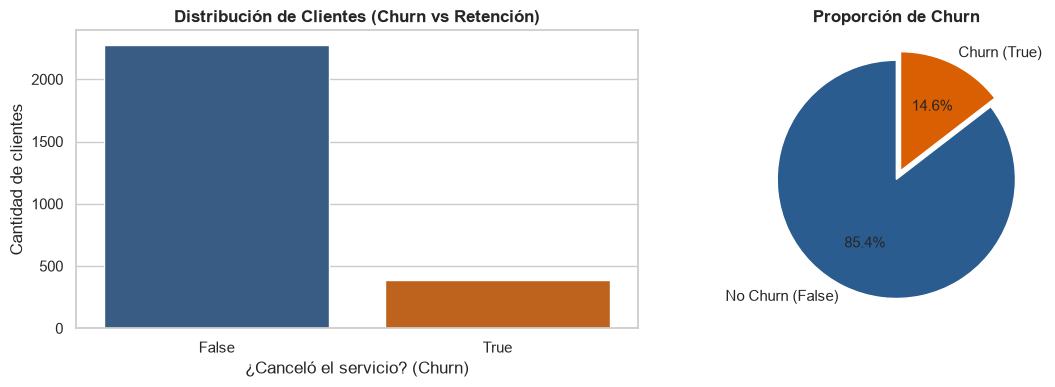

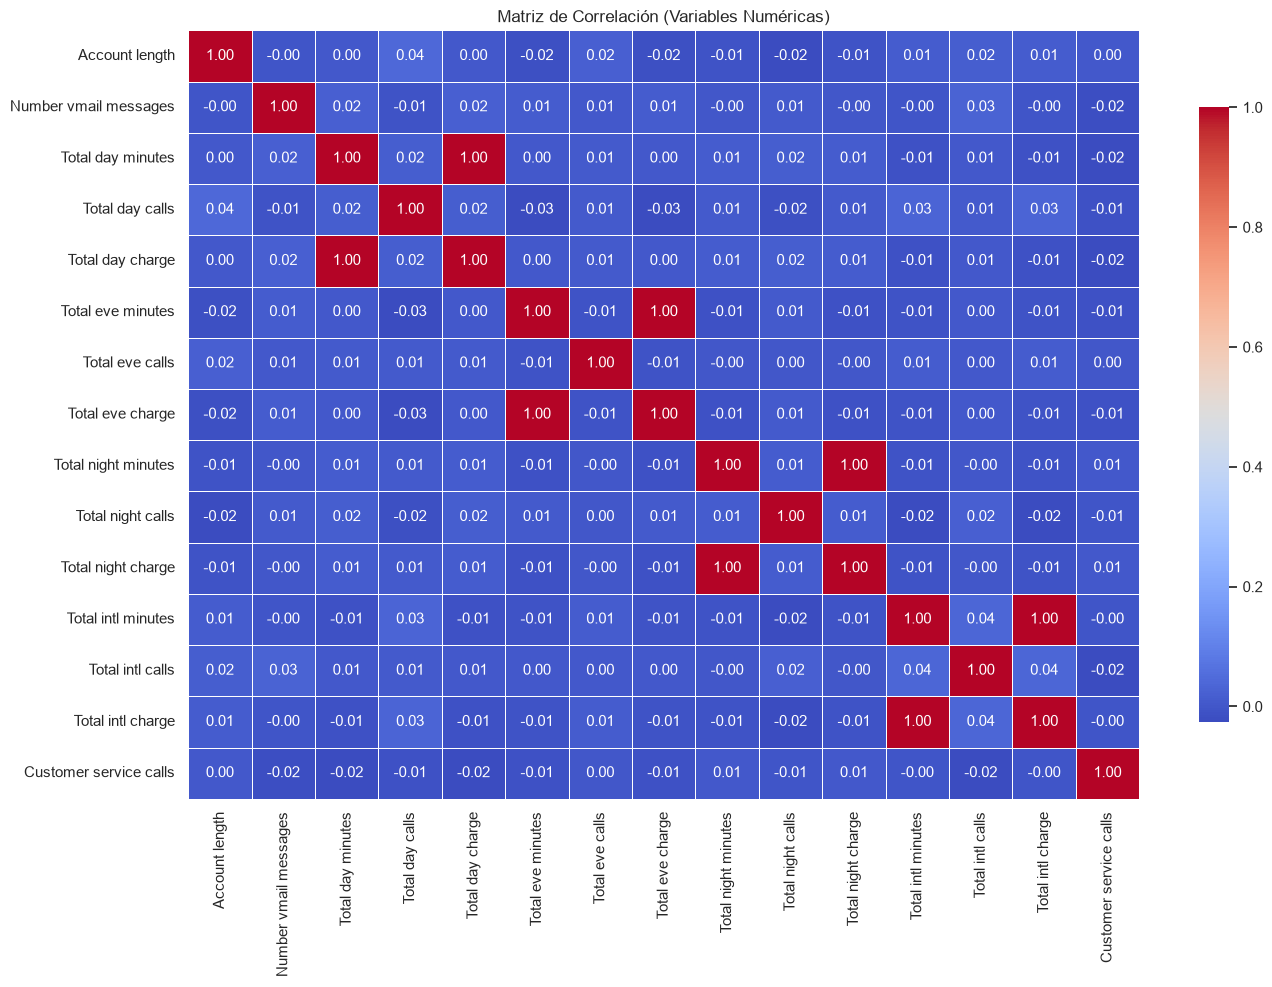

Pares con correlación superior a 0.9 (multicolinealidad crítica):
  • Total day minutes         y Total day charge          -> 1.0000
  • Total eve minutes         y Total eve charge          -> 1.0000
  • Total night minutes       y Total night charge        -> 1.0000
  • Total intl minutes        y Total intl charge         -> 1.0000


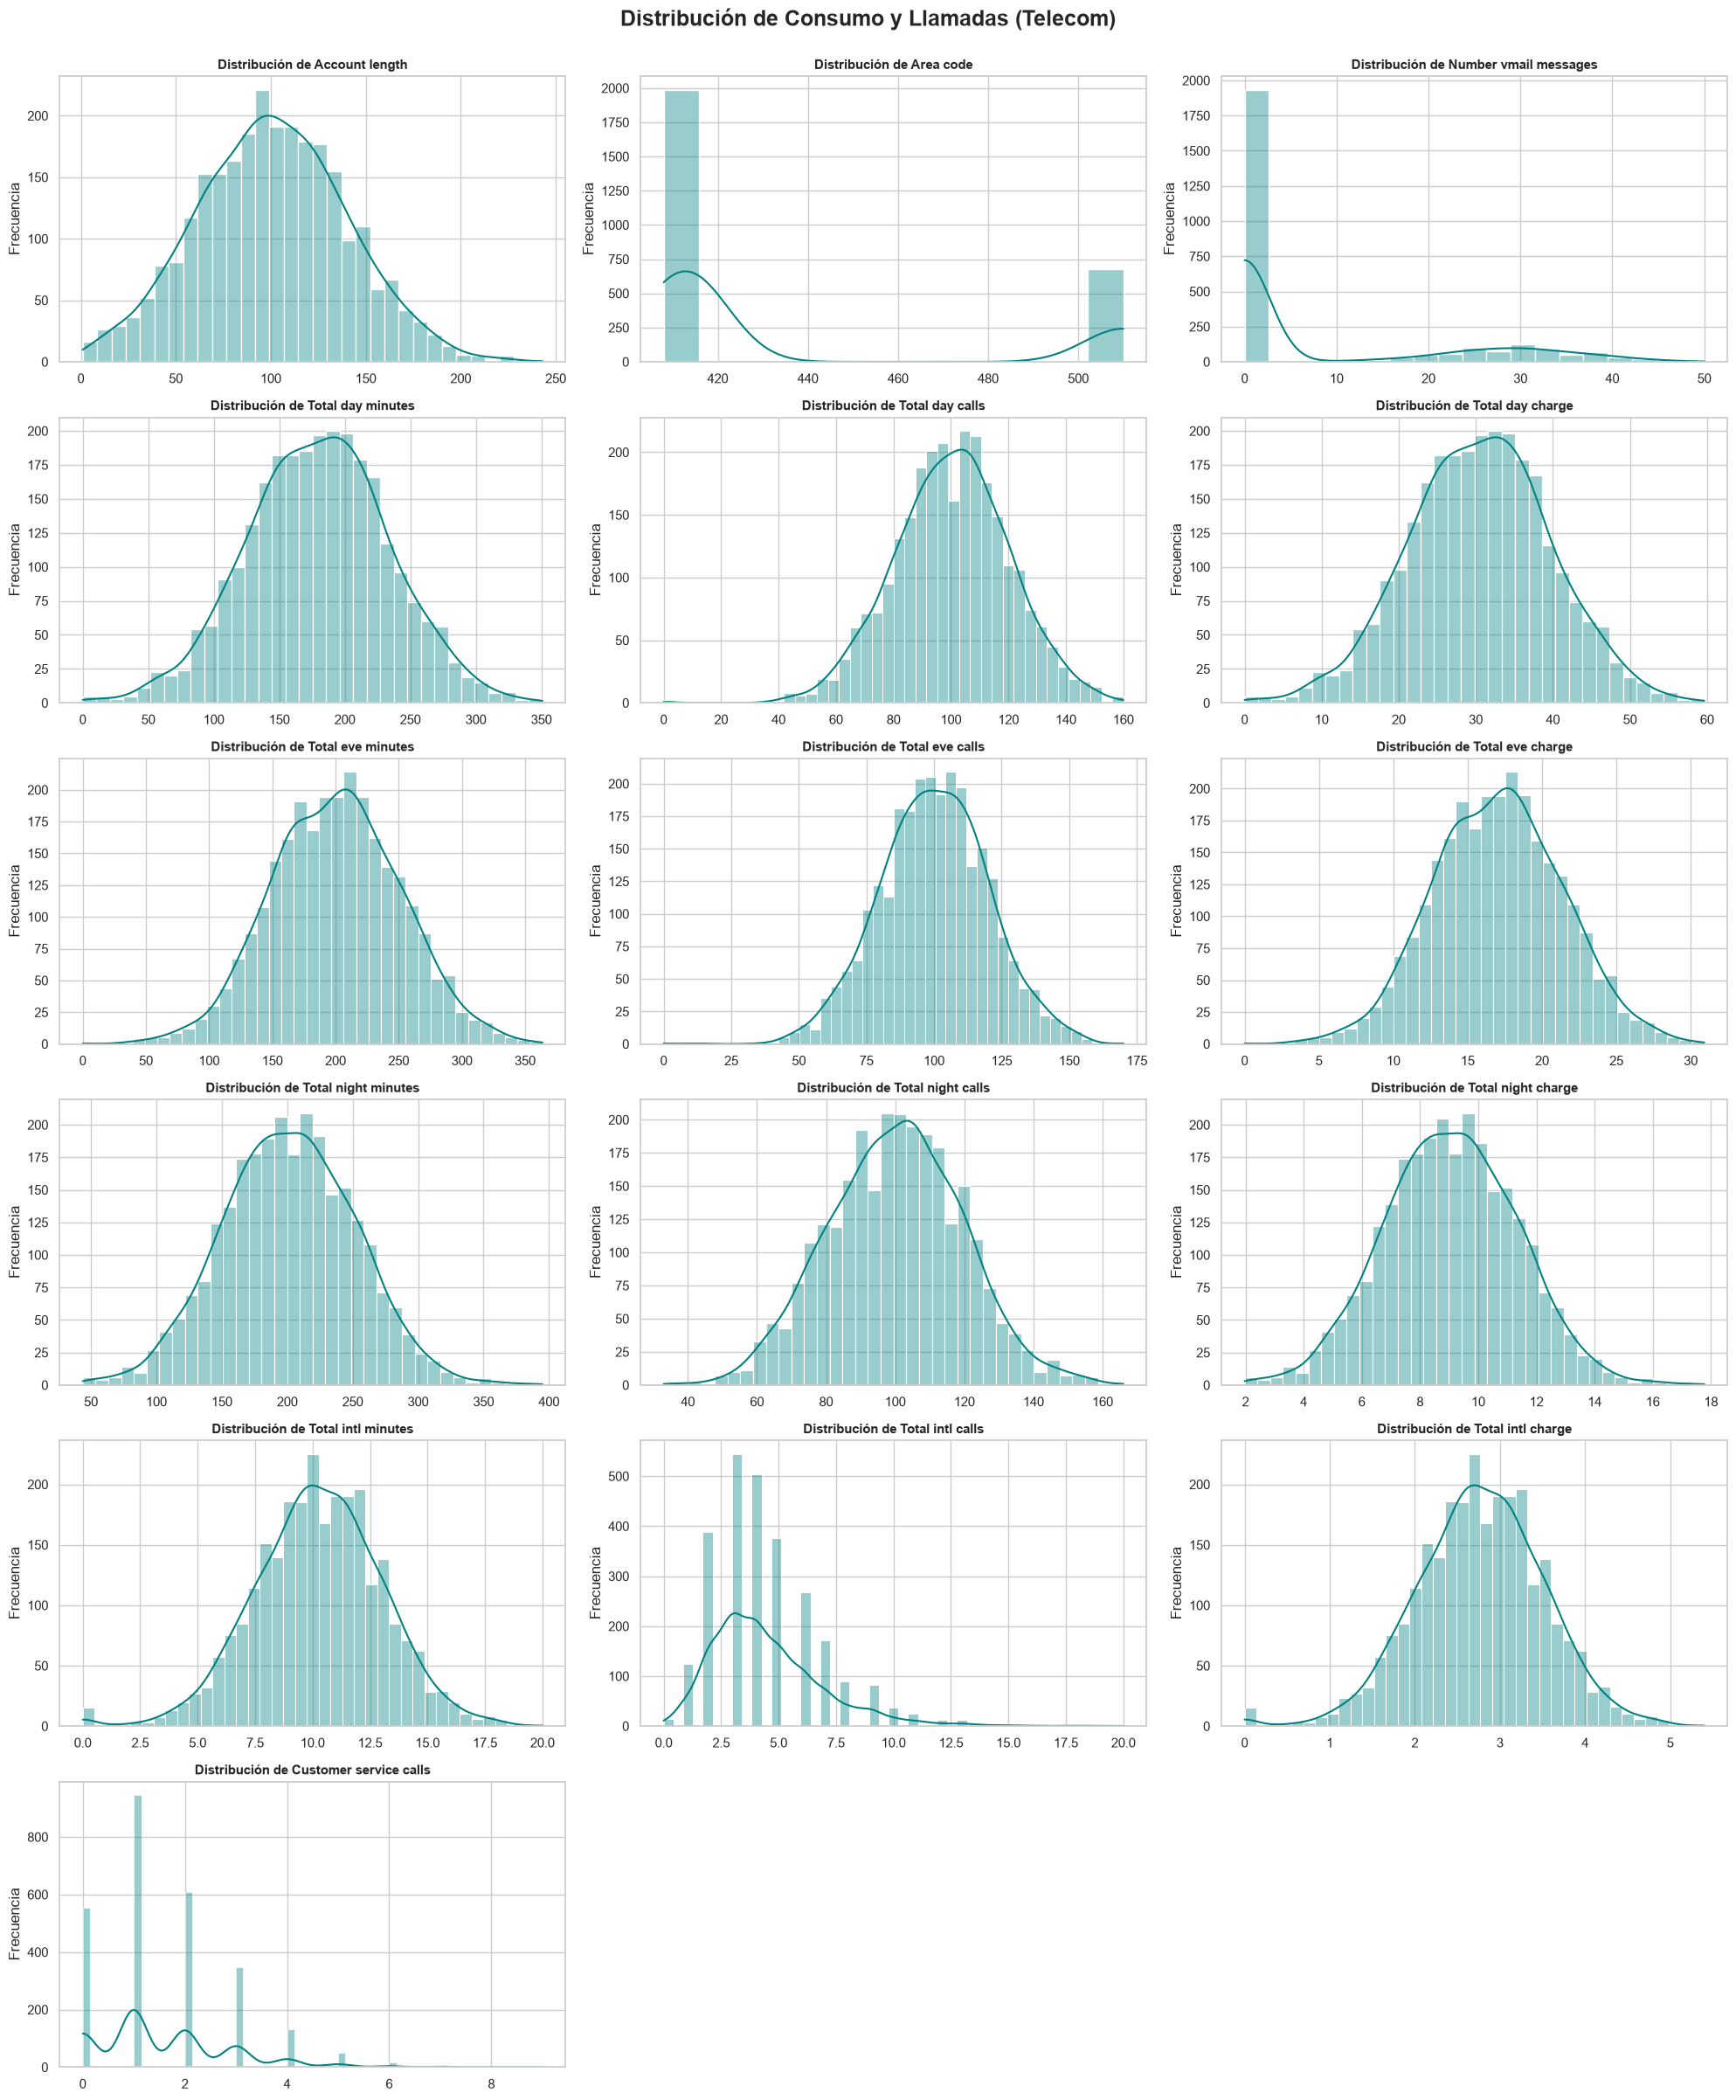

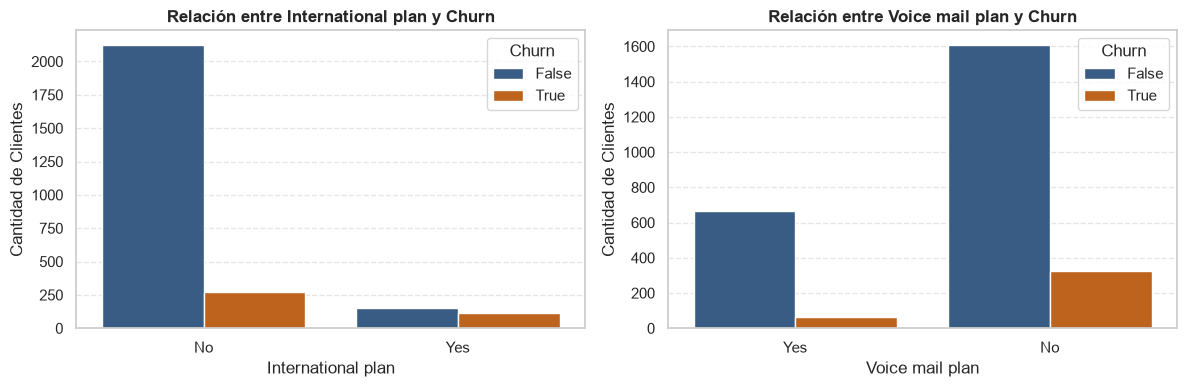

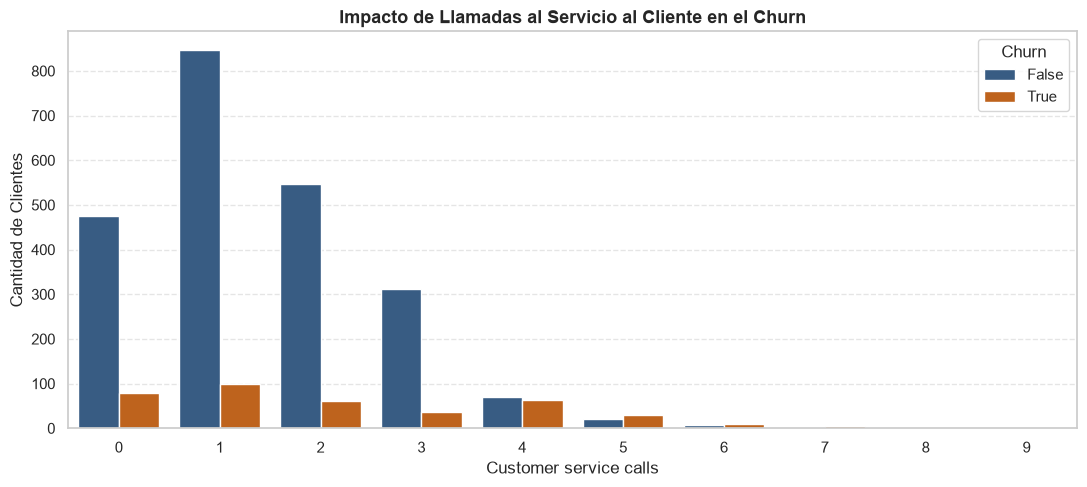

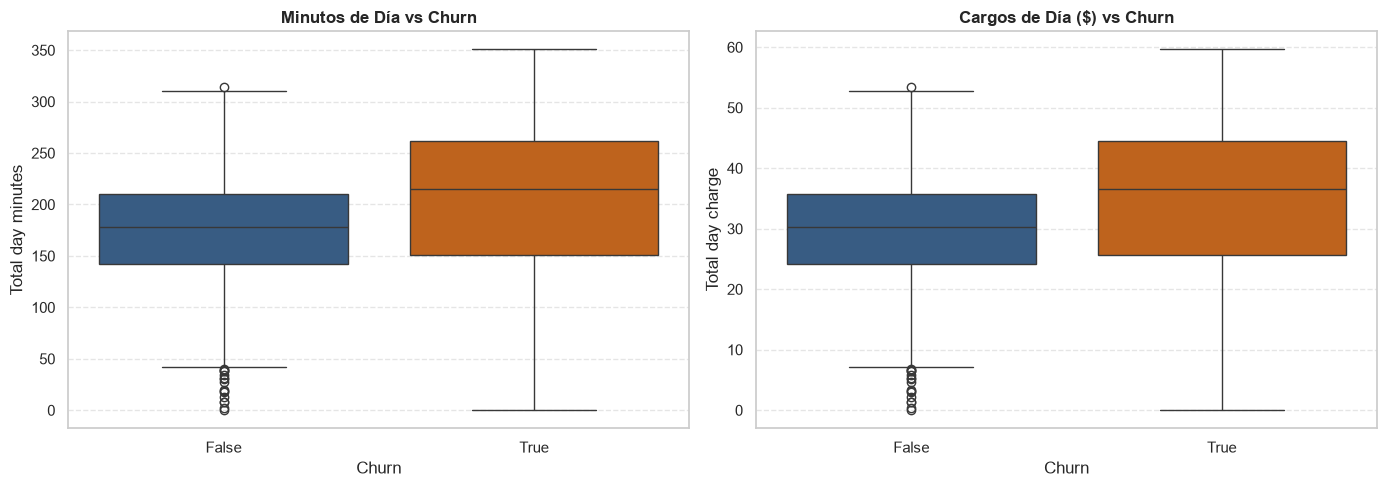

Tasa de Churn por International plan (%):
Churn                   False      True 
International plan                      
No                  88.731219  11.268781
Yes                 56.296296  43.703704 

Tasa de Churn por Voice mail plan (%):
Churn                False      True 
Voice mail plan                      
No               83.290222  16.709778
Yes              91.132333   8.867667 



In [38]:
DataExplorer.plot_target(dataset.raw)
DataExplorer.plot_correlation_matrix(dataset.raw)
DataExplorer.find_high_correlations(dataset.raw)
DataExplorer.plot_histograms(dataset.raw)
DataExplorer.plot_plans_vs_churn(dataset.raw)
DataExplorer.plot_key_predictors(dataset.raw)
DataExplorer.churn_rate_by_plan(dataset.raw)


### 3. Limpieza, partición y preprocesamiento

In [39]:
dataset.clean_data().split_data().build_preprocessor()


Duplicados eliminados: 0
Tamaño tras la limpieza: (2666, 16)
Columnas restantes: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'Churn']
=== Distribución de las Particiones ===
Muestras Train: 1866 | Tasa Churn: 0.1458
Muestras Val  : 400 | Tasa Churn: 0.1450
Muestras Test : 400 | Tasa Churn: 0.1450


### Decisiones sobre valores atípicos y casos especiales

| Variable | Hallazgo | Decisión | Justificación |
|---|---|---|---|
| `Customer service calls` | 210 outliers (7.88%) con >= 4 llamadas; churn de ___% frente a ___% en el resto | **Conservar** | No es ruido: es el predictor más fuerte de abandono. Eliminarlos quitaría justo los clientes que se quiere detectar. |
| `Total day / eve / night / intl minutes` | 21, 17, 22 y 37 outliers (0.6%–1.4%), ___ registros en total | **Conservar, sin recortar** | Son consumos altos plausibles, no errores de captura. Además, HistGradientBoosting es robusto a valores extremos (divide por umbrales). `StandardScaler` solo reescala y no los distorsiona. |
| Ceros en `Total day / eve minutes` | ___ registros con 0 minutos | **Conservar** | Corresponden a clientes con 0 llamadas en ese horario (verificado con `Total day calls` / `Total eve calls`), no a datos faltantes. |
| `State` | ___ estados, con ~___ registros cada uno | **Excluir** | Alta cardinalidad y pocos registros por categoría: el One-Hot añadiría ~50 columnas ruidosas y riesgo de sobreajuste. |
| `Area code` | 3 valores (408, 415, 510) | **Convertir a categórica** | Es un identificador nominal, no una cantidad; tratarlo como número impondría un orden falso. |
| Valores nulos y duplicados | 0 y 0 | Sin acción | Verificado en 3.2 y 3.3. |

**Nota:** los outliers se detectaron con IQR (1.5 × IQR) solo para diagnóstico. No se aplicó ningún recorte, para no perder señal predictiva ni sesgar la tasa de churn.


 JUSTIFICACIÓN TÉCNICA:
 - Total day charge, Total eve charge, Total night charge, Total intl charge:
   Presentan correlación de 1.00 con sus respectivos 'minutes'. Son una
   transformación lineal exacta (tarifa constante por minuto). Eliminar
   los cargos previene problemas de multicolinealidad en modelos lineales,
   regresiones logísticas y algoritmos basados en distancias (KNN, SVM).

### 4. Modelo base (LogisticRegression)

[Baseline_LogisticRegression_v2] Ajustando el modelo sobre Train...
Umbral óptimo en Val: 0.6732 (F1 Val: 0.6393)

=== Reporte de Clasificación en Test (Baseline_LogisticRegression_v2) ===
              precision    recall  f1-score   support

    No Churn       0.89      0.85      0.87       342
       Churn       0.31      0.40      0.35        58

    accuracy                           0.79       400
   macro avg       0.60      0.62      0.61       400
weighted avg       0.81      0.79      0.80       400

          Métrica  Puntaje
0    test_roc_auc   0.7228
1     test_pr_auc   0.3069
2     test_recall   0.3966
3  test_precision   0.3108
4   test_f1_score   0.3485


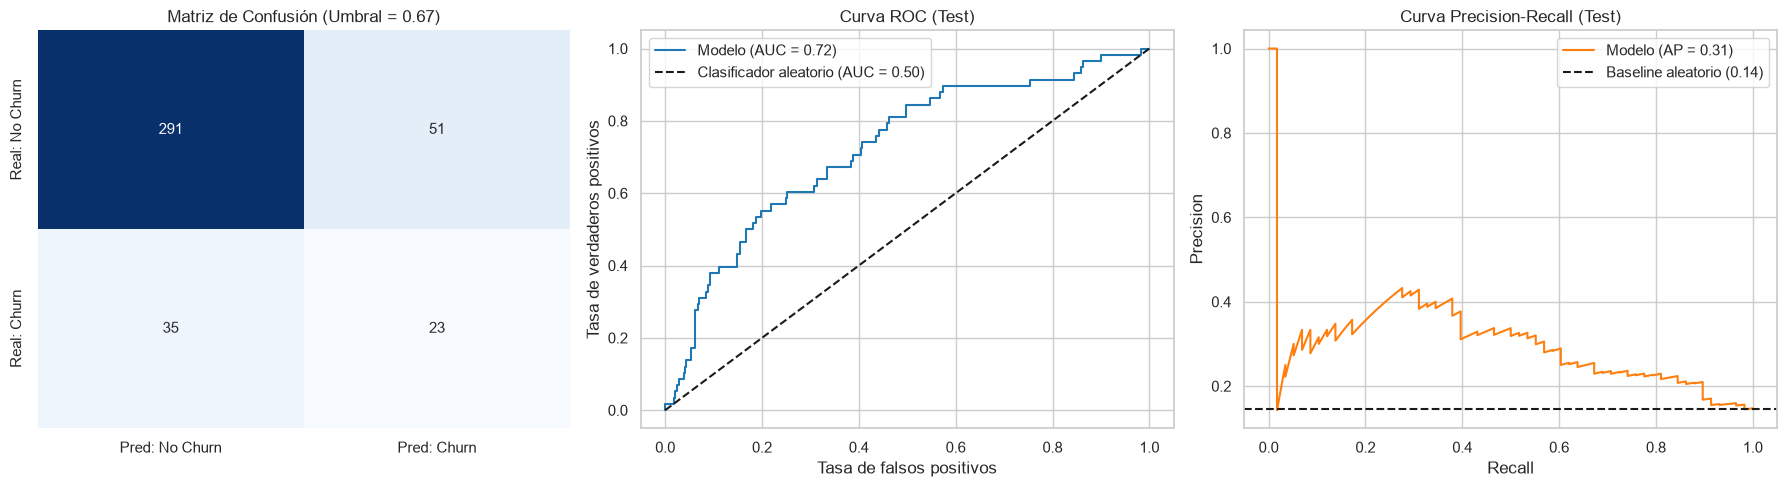

/Users/lsanchez/PycharmProjects/mlops_ccds/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/09 00:08:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, whic

🏃 View run Baseline_LogisticRegression_v2 at: http://localhost:5002/#/experiments/1/runs/09e7cbd6baec40d392b70b73200799c8
🧪 View experiment at: http://localhost:5002/#/experiments/1

RUN ID registrado en MLflow: 09e7cbd6baec40d392b70b73200799c8


In [40]:
baseline = ChurnModel(
    dataset,
    run_name="Baseline_LogisticRegression_v2",
    classifier=LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
)
baseline.train_model().select_threshold().evaluate_model().plot_diagnostics().log_to_mlflow()


### 5. Modelo ajustado (HistGradientBoosting)

[HistGradientBoosting_FineTunedv4] Búsqueda de hiperparámetros sobre Train...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Mejores parámetros: {'classifier__l2_regularization': 0.5, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__max_iter': 250, 'classifier__max_leaf_nodes': 15, 'classifier__min_samples_leaf': 20}
Mejor ROC-AUC en CV (Train): 0.9170
Umbral óptimo en Val: 0.5200 (F1 Val: 0.8966)

=== Reporte de Clasificación en Test (HistGradientBoosting_FineTunedv4) ===
              precision    recall  f1-score   support

    No Churn       0.95      0.98      0.96       342
       Churn       0.83      0.69      0.75        58

    accuracy                           0.94       400
   macro avg       0.89      0.83      0.86       400
weighted avg       0.93      0.94      0.93       400

          Métrica  Puntaje
0    test_roc_auc   0.8523
1     test_pr_auc   0.7700
2     test_recall   0.6897
3  test_precision   0.8333
4   test_f1_score

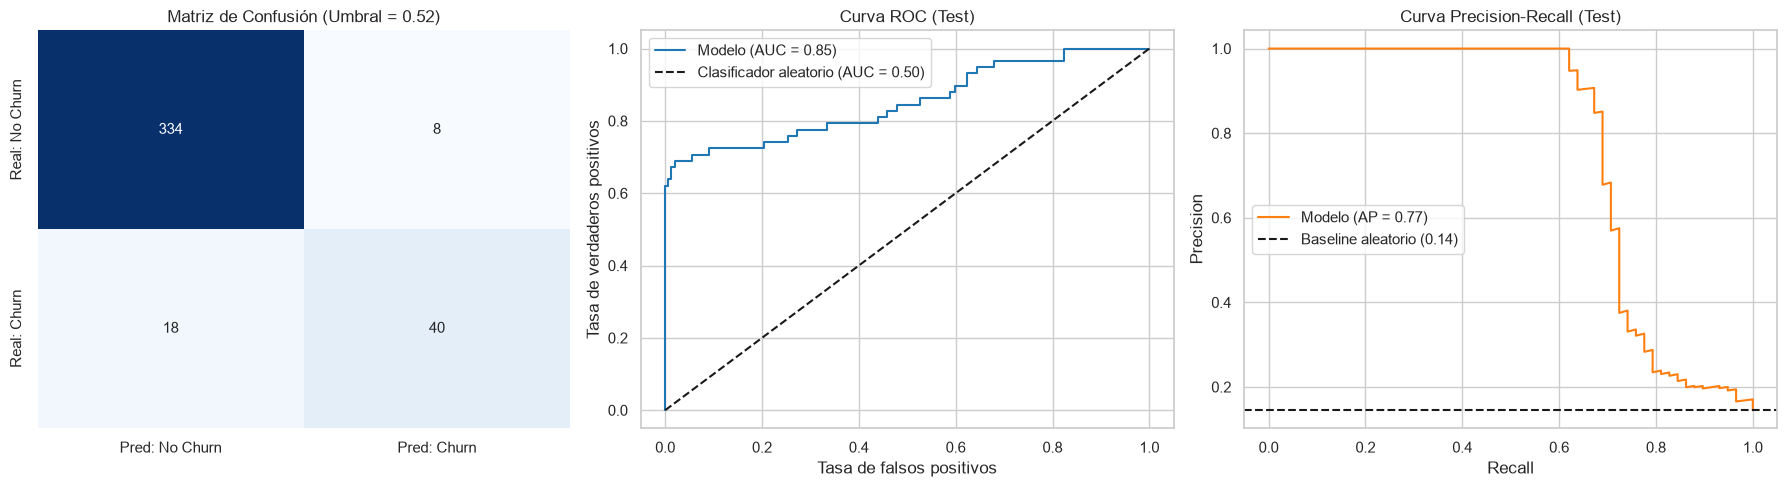

/Users/lsanchez/PycharmProjects/mlops_ccds/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/09 00:08:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, whic

🏃 View run HistGradientBoosting_FineTunedv4 at: http://localhost:5002/#/experiments/1/runs/a4ff83b2a7a54f5f93a82c097d4498b5
🧪 View experiment at: http://localhost:5002/#/experiments/1

RUN ID registrado en MLflow: a4ff83b2a7a54f5f93a82c097d4498b5


In [41]:
hgb = ChurnModel(
    dataset,
    run_name="HistGradientBoosting_FineTunedv4",
    classifier=HistGradientBoostingClassifier(
        class_weight="balanced",
        random_state=42,
        early_stopping=True,
        n_iter_no_change=15,
        tol=1e-4,
        scoring="roc_auc",
    ),
    param_grid={
        "classifier__learning_rate": [0.03, 0.06, 0.10],
        "classifier__max_iter": [250, 400],
        "classifier__max_depth": [4, 6, 8],
        "classifier__max_leaf_nodes": [15, 31],
        "classifier__min_samples_leaf": [20, 35, 50],
        "classifier__l2_regularization": [0.5, 1.5, 3.0],
    },
    thresholds=np.linspace(0.1, 0.9, 81),
)
hgb.train_model().select_threshold().evaluate_model().plot_diagnostics().log_to_mlflow()


### 6. Comparación de resultados en Test

In [42]:
pd.DataFrame({m.run_name: m.test_metrics for m in (baseline, hgb)}).round(4)


,Baseline_LogisticRegression_v2,HistGradientBoosting_FineTunedv4
test_roc_auc,0.7228,0.8523
test_pr_auc,0.3069,0.7700
test_recall,0.3966,0.6897
test_precision,0.3108,0.8333
test_f1_score,0.3485,0.7547


**Paso 7: Redacta una reflexión:**

Al final del notebook, explica brevemente qué mejorarías en este flujo aplicando prácticas de MLOps y por qué.
¿Cómo se ven reflejados estos aprendizajes dentro de tu área profesional?
150 palabras o más de extensión.


### Conclusiones, Mejoras Futuras en MLOps e Impacto Profesional

#### 1. Mejoras en el flujo aplicando prácticas de MLOps
Aunque la estructuración del pipeline actual y el seguimiento de experimentos con MLflow sientan una base sólida, la transición hacia un entorno productivo robusto demanda optimizaciones clave:
* **Infraestructura y disponibilidad en la nube:** Resulta indispensable desacoplar la ejecución local y migrar el ciclo de vida del modelo hacia servicios administrados en la nube (como AWS o GCP), garantizando alta disponibilidad (24/7) y escalabilidad mediante contenedores y orquestación.
* **Seguridad y gobernanza de datos:** Al procesar información sensible de clientes en el sector de telecomunicaciones, es prioritario implementar controles estrictos de seguridad, cifrado en tránsito y en reposo, anonimización/tokenización y políticas de gobernanza que prevengan la fuga de datos confidenciales.
* **Automatización del ciclo de vida (CI/CD/CT):** Se debe incorporar monitoreo continuo de *data drift* y *concept drift* para detectar la degradación del modelo, activando pipelines automatizados de reentrenamiento y validación de versiones antes de su despliegue productivo.

#### 2. Reflejo de los aprendizajes en el ámbito profesional
La selección del caso de uso de *Customer Churn* responde directamente a mi actividad en la industria de telecomunicaciones, donde la retención de suscriptores representa una de las métricas comerciales más críticas. En un mercado altamente dinámico y con desafíos regulatorios como el mexicano, anticiparse al abandono permite activar mecanismos proactivos de retención, atención personalizada y compensación al cliente antes de que la decisión de baja sea definitiva.

Comprender el ciclo integral de MLOps —desde el establecimiento del *baseline* hasta el ajuste fino de modelos con métricas de alto rendimiento y trazabilidad en MLflow— valida la viabilidad técnica para transferir este flujo a producción dentro de la empresa. Más allá de este caso específico, estos aprendizajes sientan un precedente metodológico para estandarizar y replicar arquitecturas de aprendizaje automático orientadas a la optimización de procesos y toma de decisiones estratégicas en el negocio.

#### 3. Comentarios y reflexiones personales
A nivel personal, disfruté mucho el desarrollo de esta actividad adoptando prácticas formales de MLOps, ya que me permitió vivir de primera mano el valor de la trazabilidad, la experimentación estructurada y el 360 que cubre al modelo. Fue sumamente satisfactorio ver la evolución real del proyecto: partir de un modelo base inicial (*baseline*) y llevarlo de forma iterativa y fundamentada hasta un modelo final con métricas muy sólidas y competitivas, listas para resolver un problema de negocio tangible en un problema en el que me enfrento día con día. Esta experiencia me confirma que el esfuerzo no se queda en un ejercicio académico; me deja un estándar de trabajo claro y un flujo metodológico probado que sin duda buscaré replicar y extender a otros casos de uso analíticos en mi día a día.

**Paso 8: Referencias:**

* Ascarza, E., Neslin, S. A., Netzer, O., Anderson, Z., Fader, P. S., Gupta, S., Lattin, J. M., Lemmens, A., Libai, B., Neal, M. B., Neslin, S. A., & Yildiz, E. (2018). In pursuit of enhanced customer retention management: Review, key issues, and future directions. *Customer Needs and Solutions*, *5*(1–2), 65–81. https://doi.org/10.1007/s40547-017-0080-0
* Anthropic. (2024). Claude 3.5 Sonnet [Modelo de lenguaje de gran tamaño]. Utilizado para mejorar la sintaxis del código y para comentar el código de manera uniforme. https://claude.ai/
* Kreuzberger, D., Kühl, N., & Hirschl, S. (2023). Machine learning operations (MLOps): Overview, definition, and architecture. *IEEE Access*, *11*, 31866–31879. https://doi.org/10.1109/ACCESS.2023.3262138
* Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.
* Zaharia, M., Chen, A., Davidson, A., Ghodsi, A., Hong, S. A., Konwinski, A., Murching, S., Nykodym, T., Ogilvie, P., Parkhe, M., Xie, F., & Zumar, C. (2018). Accelerating the machine learning lifecycle with MLflow. *IEEE Data Engineering Bulletin*, *41*(4), 39–45.

